# Standard Problem for materials with Dzyaloshinskii-Moriya interaction


## Google Colab Link

The demo can be run on Google Colab without any local installation.
Use the following [link](https://colab.research.google.com/drive/1wrQL5javKqgW6pnBzFYp5T99TTVYX7sB#scrollTo=755d81e8) to try out.

## Install magnum.np and download reference data if not available

In [3]:
!pip install -q magnumnp numpy==1.22.4

In [2]:
from os import path
if not path.isdir("ref"):
    !mkdir ref
    !wget -P ref https://gitlab.com/nina_sturm/magnum.np/raw/main/demos/sp_DMI/ref/interfaceDMI_mx.dat
    !wget -P ref https://gitlab.com/nina_sturm/magnum.np/raw/main/demos/sp_DMI/ref/interfaceDMI_mz.dat

## Run Demo:

In [ ]:
from magnumnp import *
import torch
import numpy as np
import os
import math

Timer.enable()

n  = (100, 1, 1)
dx = (1e-9, 1e-9, 1e-9)
origin = (-n[0]*dx[0]/2., -n[1]*dx[1]/2., -n[2]*dx[2]/2.,)

mesh = Mesh(n, dx, origin)
state = State(mesh)
state.material = {
    "alpha": 1.,
    "A": 13e-12,
    "Ms": 800e3,
    "Di": -3e-3,
    "Ku": 0.4e6,
    }
state.material['Ku_axis'] = [0,0,1]
x, y, z = state.SpatialCoordinate()


state.material['A'] =  state.Constant([13e-12])
state.material['Ms'] = state.Constant([0.86e6])
state.material['Di'] = state.Constant([-3e-3])
state.material['Ku'] = state.Constant([0.4e6])


write_vti(state.material, "data/material.vti", state)

state.m = state.Constant([-0.1, 0.0, 0.9])
state.m.normalize()

exchange = ExchangeField()
aniso    = UniaxialAnisotropyField()
dmi = InterfaceDMIField()
write_vti(exchange.h(state), "data/h0_exchange.vti", state)
write_vti(aniso.h(state), "data/h0_aniso.vti", state)

llg = LLGSolver([exchange, aniso, dmi])
logger = ScalarLogger("data/m_relax.dat", ['t', 'm'])
while state.t <= 5e-9:
    logger << state
    llg.step(state, 1e-12)
write_vti(state.m, "data/m_relax.vti", state)
np.savetxt("data/m0_magnumnp.dat", torch.concat((x[:,0,0,None], state.m[:,0,0,:]), axis=1).cpu().numpy())

Timer.print_report()

## Plot Results

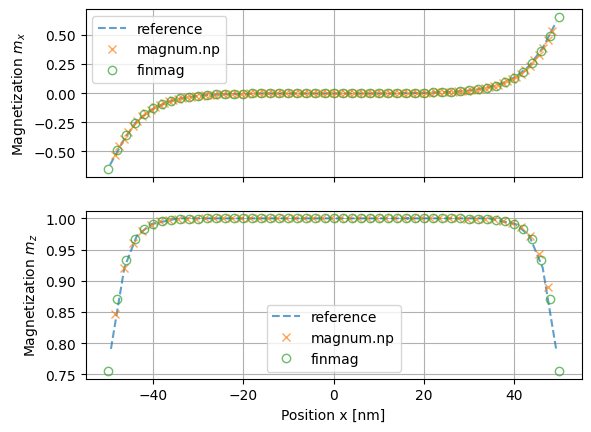

In [7]:
import matplotlib.pyplot as plt

magnumnp = np.loadtxt("data/m0_magnumnp.dat")
#magnumpi = np.loadtxt("data/m0_magnumpi.dat")
finmag = np.loadtxt("data/m0_finmag.dat")

ref_x = np.loadtxt("ref/interfaceDMI_mx.dat")
ref_z = np.loadtxt("ref/interfaceDMI_mz.dat")

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, (ax1,ax2) = plt.subplots(nrows=2, sharex=True)
ax1.plot(ref_x[:,0], ref_x[:,1], "--", color=cycle[0], alpha = 0.7, label = r"reference")
ax1.plot(magnumnp[1:-1,0]*1e9, magnumnp[1:-1,1], "x", color=cycle[1], alpha = 0.7, label = "magnum.np")
ax1.plot(finmag[::2,0]-50., finmag[::2,1], "o", mfc='none', color=cycle[2], alpha = 0.7,  label = "finmag")
ax1.set_ylabel("Magnetization $m_x$")

ax2.plot(ref_z[:, 0], ref_z[:,1], "--", color=cycle[0], alpha = 0.7, label = r"reference")
ax2.plot(magnumnp[1:-1:2,0]*1e9, magnumnp[1:-1:2,3], "x", color=cycle[1], alpha = 0.7, label = "magnum.np")
ax2.plot(finmag[::2,0]-50., finmag[::2,3], "o", mfc='none', color=cycle[2], alpha = 0.7, label = "finmag")
ax2.set_ylabel("Magnetization $m_z$")

for ax in ax1, ax2:
    ax.legend()
    ax.grid()
ax2.set_xlabel("Position x [nm]")
fig.savefig("data/results.png")